In [2]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc


import re # for string cleaning


In [3]:
# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        # print(archive)
        return archive
        # chip = archive['chip']
        # data = archive['data'].item()
        # return chip, data
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None

In [4]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [9]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
# LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/abi_east_geo_topo_lomsk.nc"
LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong == -999] = 10
abiLat[abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(abiLat.shape)

(10848, 10848)


In [10]:
def visualize_chips(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))

    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
    # print(img_extent)

    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot

    # plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')

    # plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image, cmap='gray') 
    # plt.imshow(abi_image) 

    # 4. Add a colorbar so you know what the values mean
    # plt.colorbar(label='Radiance')

    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are the transect 
    plt.plot(cloudsat_longitude, cloudsat_latitude, color='red', linewidth=2, label='CloudSat Track')

    # 6. Add labels and a title
    plt.title("ABI Chip with CloudSat Transect Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()

    # 7. Show the plot
    plt.show()

In [11]:


output_directory = '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound'

files = find_npz_files(output_directory)

print(files)
print(len(files))

start = 0


files = files[start:start+3] # only wanna take 3 so it doesn't overload

['/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165028Z_orbit68982_r5098_c8446_p18810_len489.npz', '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165035Z_orbit68982_r5051_c8436_p18855_len490.npz', '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165042Z_orbit68982_r5004_c8426_p18900_len490.npz', '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165049Z_orbit68982_r4957_c8415_p18945_len491.npz', '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165056Z_orbit68982_r4910_c8405_p18990_len491.npz', '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165104Z_orbit68982_r4863_c8394_p19035_len491.npz', '/explore/nobackup/pr

/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165028Z_orbit68982_r5098_c8446_p18810_len489.npz
(7, 512, 512, 16)
489


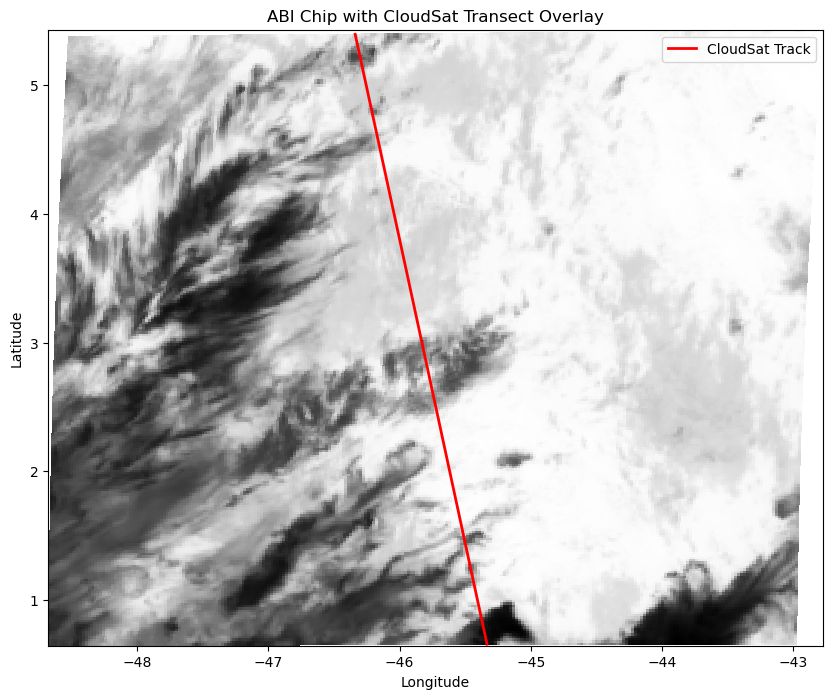

/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165035Z_orbit68982_r5051_c8436_p18855_len490.npz
(7, 512, 512, 16)
490


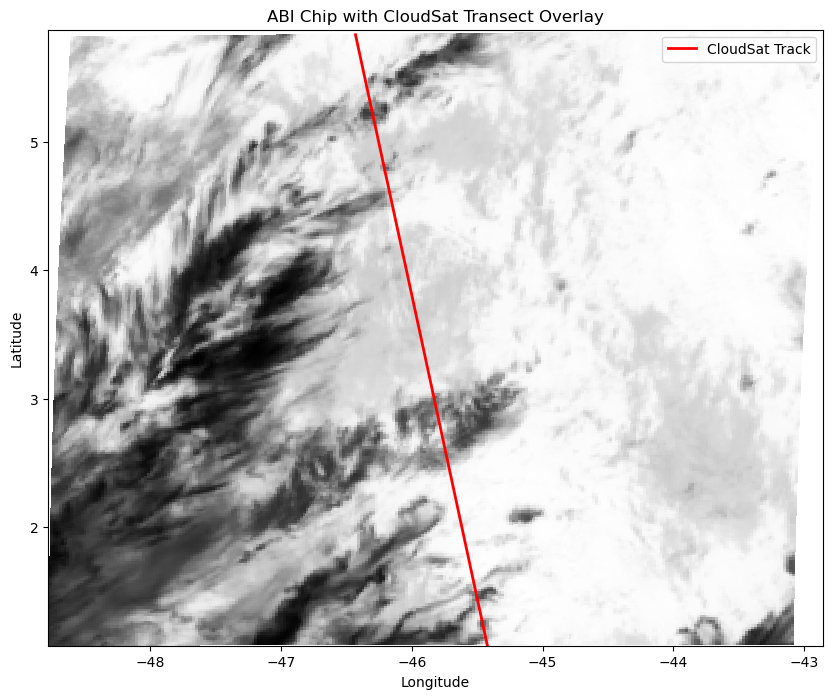

/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound/GOES16_east_abi_cloudsat_20190410T165042Z_orbit68982_r5004_c8426_p18900_len490.npz
(7, 512, 512, 16)
490


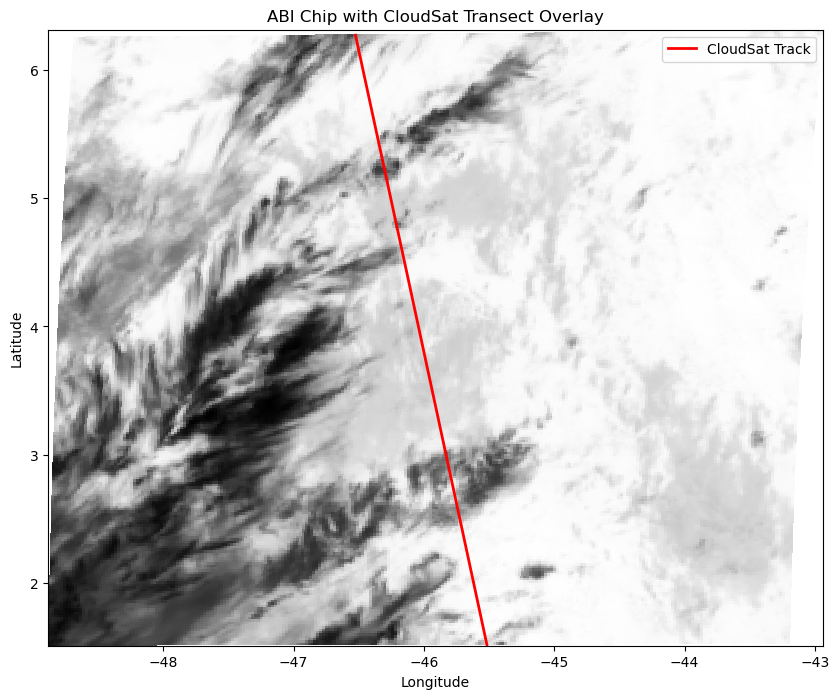

In [12]:
half = 256

for file in files:
    print(file)
    archive = open_npz_file(file)


    # print(archive.files)

    chip = archive['chip']
    print(chip.shape)

    cloudsat_latitude = archive['cloudsat_latitude'] 
    cloudsat_longitude = archive['cloudsat_longitude'] 
    # cloudsat_longitude[cloudsat_longitude < 0] += 360

    # print(cloudsat_latitude.shape, cloudsat_longitude.shape)

    #  'cloudsat_latitude', 'cloudsat_longitude' is what we need for the vis

    # print(archive['cloudsat_latitude'].shape) # it matches the len which is a good sign

    fileName = file.split('/')[-1]
    # print(fileName) # GOES16_east_abi_cloudsat_20190410T151908Z_orbit68981_r2556_c9238_p21510_len603.npz
    # r c p is row column is profile index

    fileNameSplit = fileName.split('_')
    # print(fileNameSplit)

    row =re.sub(r'[^0-9]', '', fileNameSplit[-4]) 
    col = re.sub(r'[^0-9]', '', fileNameSplit[-3])
    length = re.sub(r'[^0-9]', '', fileNameSplit[-1])
    print(length)

    # print(row, col, length)

    y_center = int(row)
    x_center = int(col)

    # abiLatCenter
    # abiLonCenter

    # cloudsatLatCenter = cloudsat_latitude[len(cloudsat_latitude)//2]
    # cloudsatLonCenter = cloudsat_longitude[len(cloudsat_longitude)//2]

    # print(cloudsatLatCenter, cloudsatLonCenter)


   
    
    lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]

    
    abi_image = chip[2, :, :, 12]
    visualize_chips(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude)
    

   
    


## analysis

In [15]:

def plot(lon, lat, length, sat, bound):
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))
    
    fig.suptitle(f'Scatter Plot for goes{sat}, bound {bound}')

    # Top-Left Plot
    sc = ax[0, 0].scatter(lon, lat, c=length, cmap='plasma', s=100, vmin=478, vmax=763, edgecolors='none')

    # FIX: Anchor the colorbar ONLY to ax[0, 0] so it doesn't distort the rest of the grid
    fig.colorbar(sc, ax=ax[0, 0], label='Length of transect', pad=0.05)
    
    ax[0, 0].set_xlabel('Longitude')
    ax[0, 0].set_ylabel('Latitude')
    # ax[0, 0].set_title(f'Scatter Plot for goes{sat}, bound {bound}')
    ax[0, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Bottom-Left Plot
    ax[1, 0].scatter(lon, length, s=50, edgecolors='none')
    ax[1, 0].set_xlabel('Longitude')
    ax[1, 0].set_ylabel('Length')
    # ax[1, 0].set_title(f'Scatter Plot for goes{sat}, bound {bound}')
    ax[1, 0].grid(True, linestyle='--', alpha=0.5)

    # Top right Plot
    ax[1, 1].scatter(lat, length, s=50, edgecolors='none')
    ax[1, 1].set_xlabel('latitude')
    ax[1, 1].set_ylabel('Length')
    # ax[1, 1].set_title(f'Scatter Plot for goes{sat}, bound {bound}')
    ax[1, 1].grid(True, linestyle='--', alpha=0.5)
    
    # ax[1, 1].axis('off')
    # ax[1, 0].axis('off')
    
    
# Calculate statistics using numpy
    stats_text = (
        f"--- Summary Statistics ---\n\n"
        f"Total Chips: {len(length)}\n"
        f"Mean Length: {np.mean(length):.2f}\n"
        f"Median Length: {np.median(length):.2f}\n"
        f"Min Length: {np.min(length):.2f}\n"
        f"Max Length: {np.max(length):.2f}\n"
        f"Std Dev: {np.std(length):.2f}"
    )
    
    # Hide the graph axis elements (ticks, spine borders) to make it a blank text box
    ax[0, 1].axis('off')
    
    # Render the text onto the canvas using relative coordinates (0 to 1)
    ax[0, 1].text(0.1, 0.8, stats_text, fontsize=12, family='monospace', verticalalignment='top')    

    plt.tight_layout()
    plt.show()


/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/1600_bound/GOES16_east_abi_cloudsat_20190410T163932Z_orbit68982_r8952_c8386_p14715_len701.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/1600_bound/GOES16_east_abi_cloudsat_20190411T155945Z_orbit68996_r1719_c8129_p22500_len700.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/1600_bound/GOES16_east_abi_cloudsat_20190411T171725Z_orbit68997_r9029_c7754_p14670_len701.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/1600_bound/GOES16_east_abi_cloudsat_20190411T173810Z_orbit68997_r1669_c6352_p22455_len700.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/1600_bound/GOES16_east_abi_cloudsat_20190411T185542Z_orbit68998_r9155_c5817_p14580_len701.npz


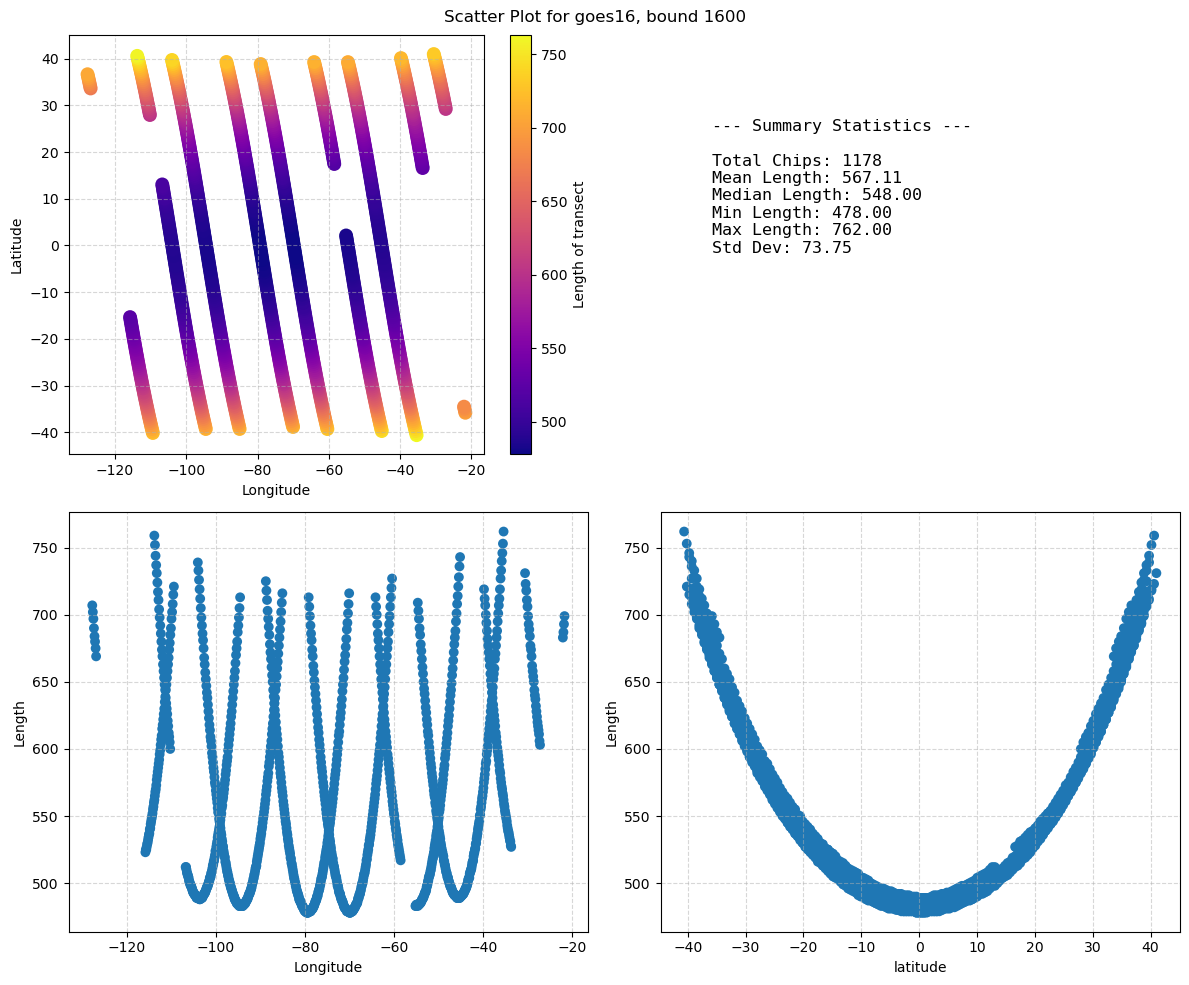

/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T201722Z_orbit68984_r1707_c7976_p22500_len700.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T213501Z_orbit68985_r9038_c7582_p14670_len700.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T215547Z_orbit68985_r1665_c6155_p22455_len700.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T231319Z_orbit68986_r9157_c5615_p14580_len701.npz
/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190411T191649Z_orbit68998_r1789_c8822_p22500_len701.npz


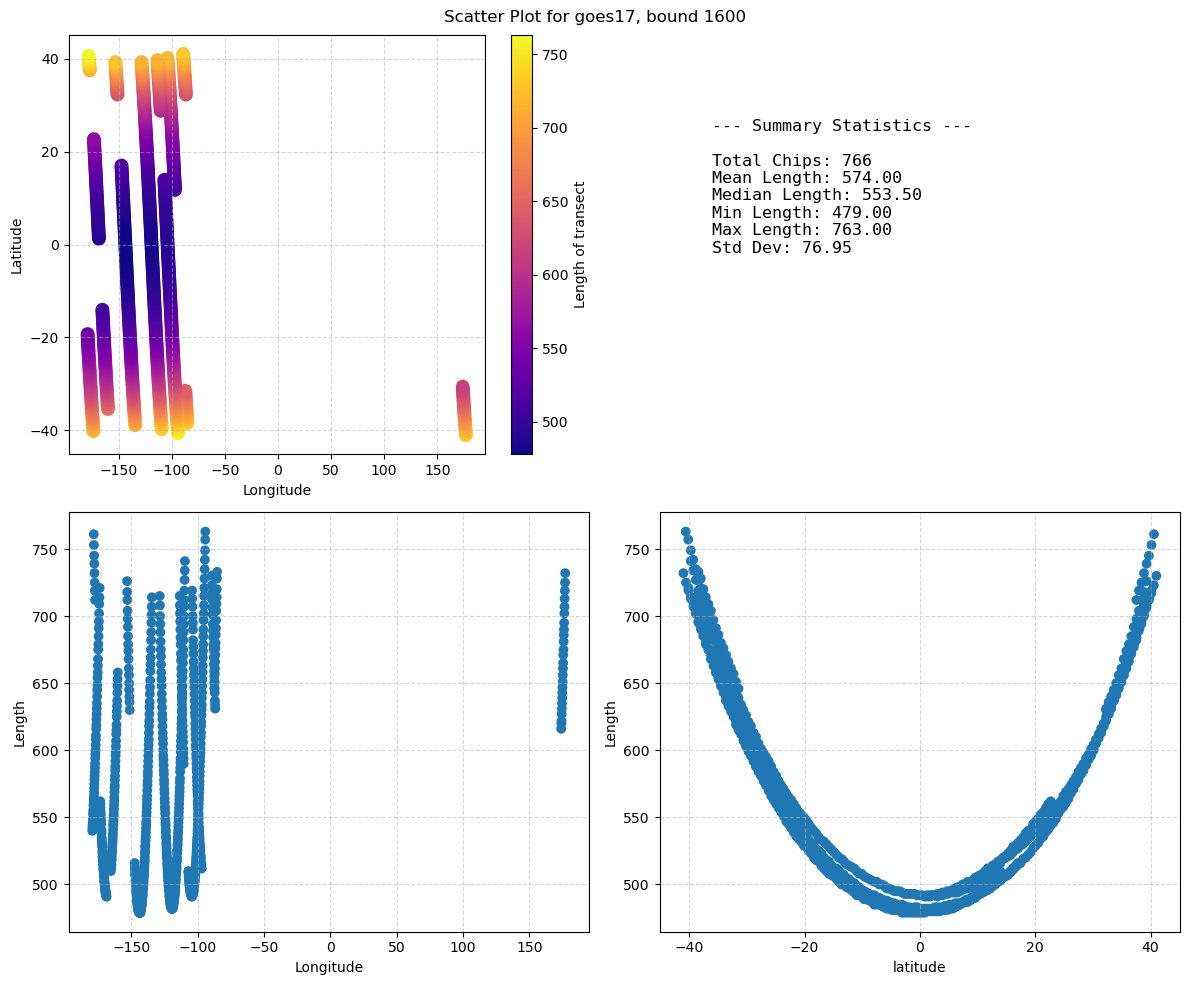

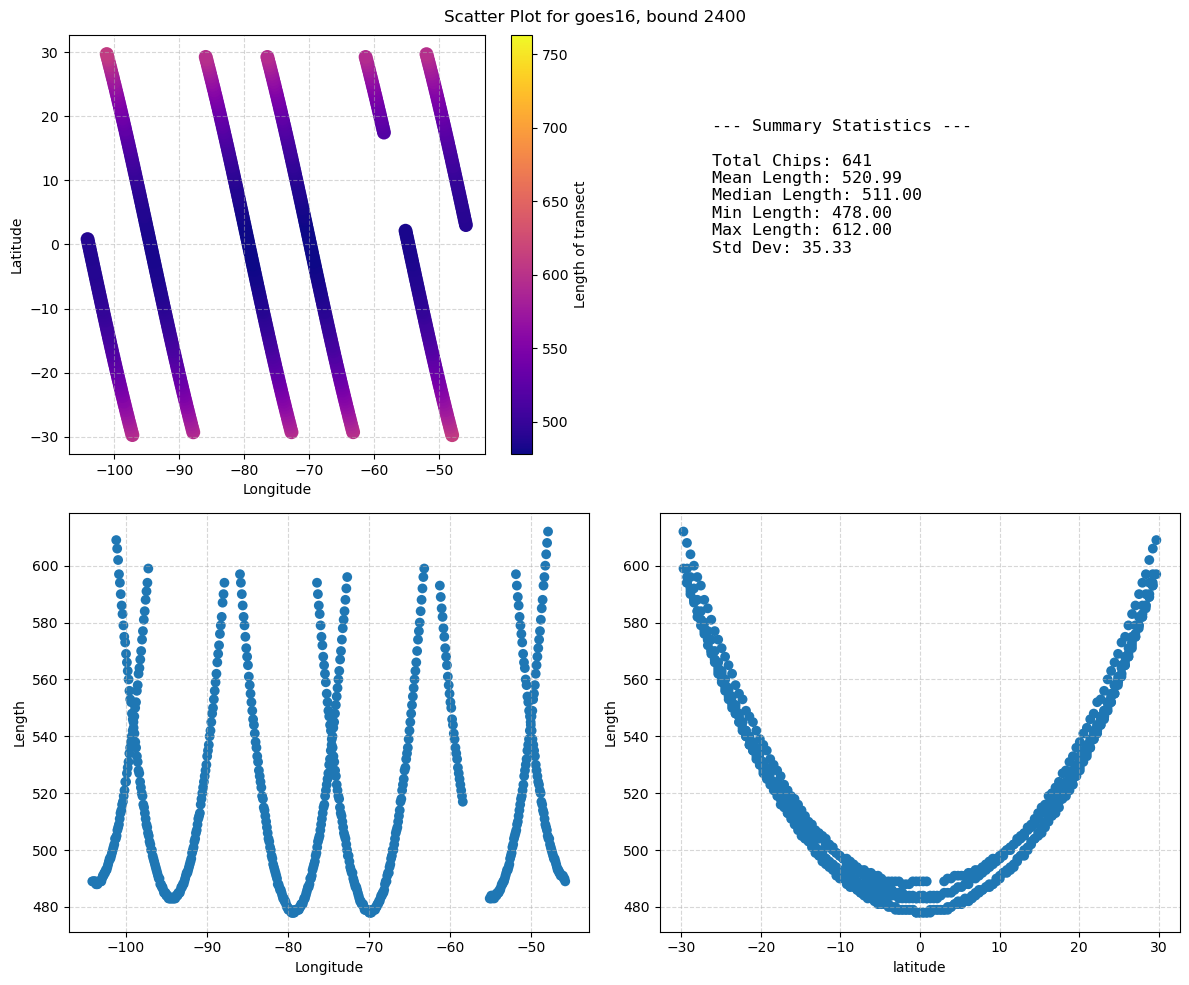

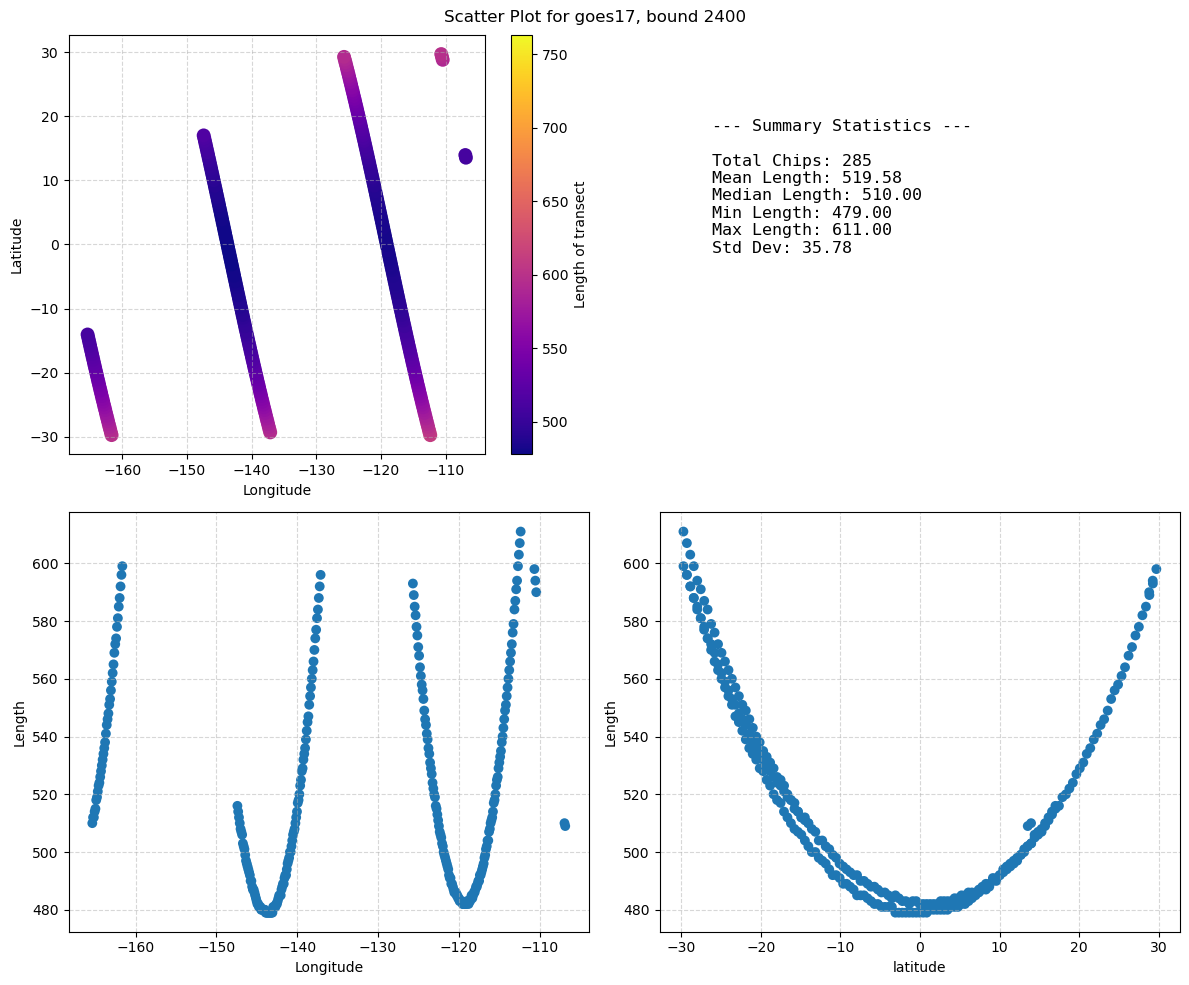

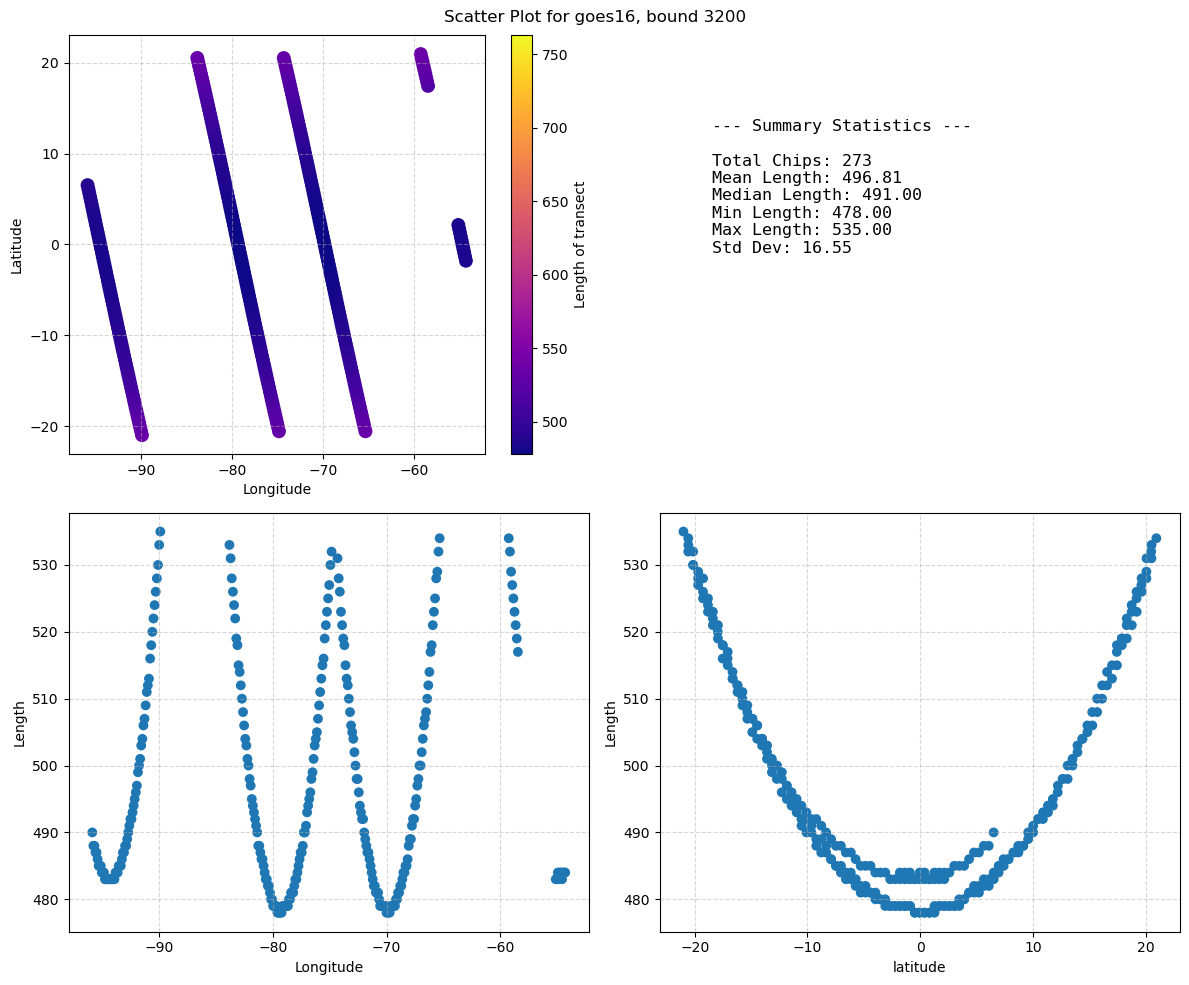

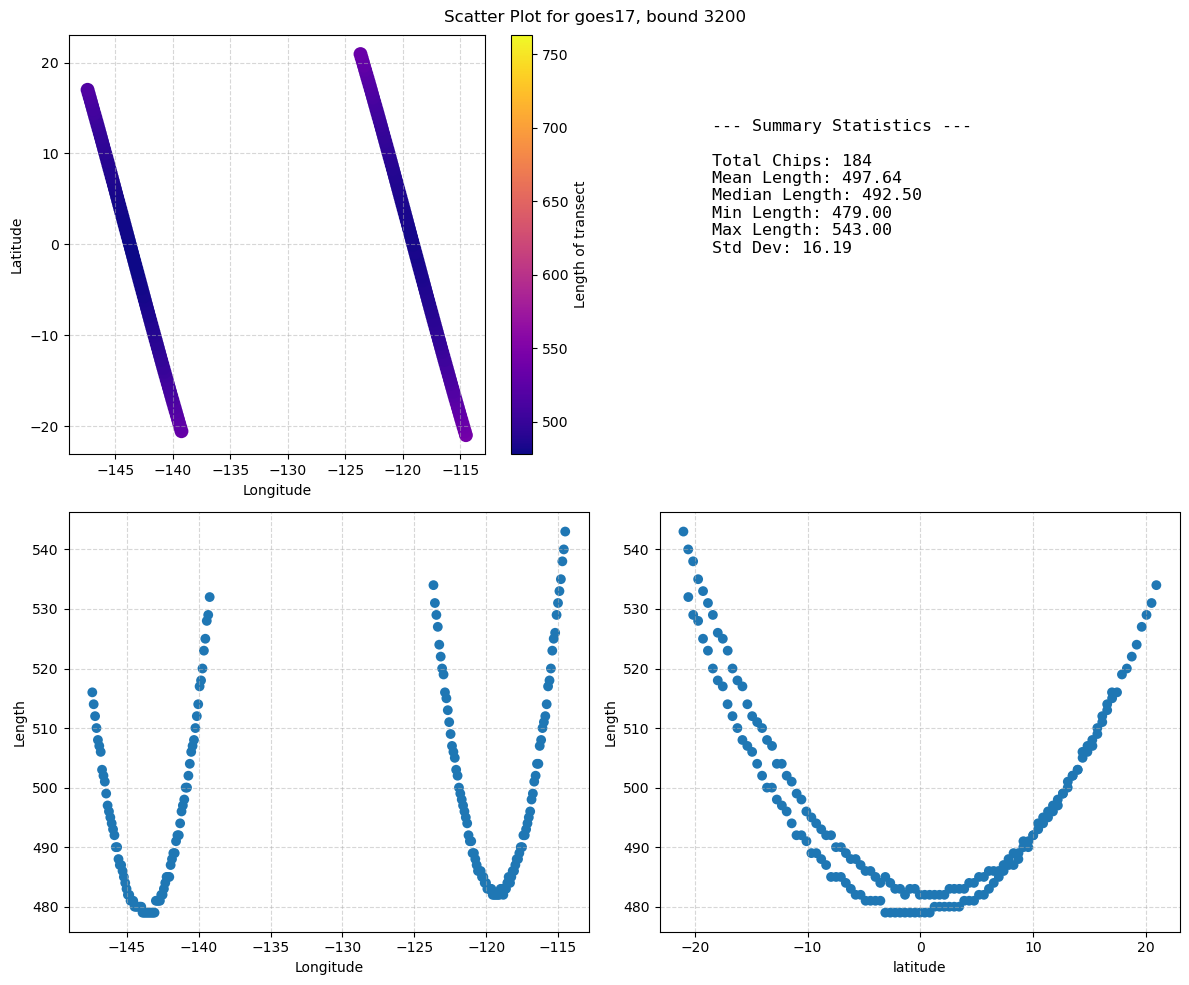

In [16]:
# directory structure where the chips are for diff sateliets and bounds
# /explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes16/2400_bound


# get all files

# Goes 16 and 19 are east
# 17 and 18 are west 

bounds = [1600, 2400, 3200]
sats = [16, 17, 18, 19]

for bound in bounds:
    for sat in sats:
        directory = f'/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes{sat}/{bound}_bound'

        files = find_npz_files(directory)
        if len(files) != 0:

            # print(f'There are {len(files)} files in the goes{sat}, bound {bound} directory')

            lon = []
            lat = []
            length = []

            for file in files:
                archive = open_npz_file(file)

                cloudsat_latitude = archive['cloudsat_latitude'] 
                cloudsat_longitude = archive['cloudsat_longitude'] 

                transectLength = len(cloudsat_latitude)
                cloudsatLatCenter = cloudsat_latitude[transectLength//2]
                cloudsatLonCenter = cloudsat_longitude[transectLength//2]

                minToView = 700
                maxToView = 701
                
                if minToView <= transectLength and transectLength <= maxToView:
                    print(file)

                lon.append(cloudsatLonCenter)
                lat.append(cloudsatLatCenter)
                length.append(transectLength)

            # print(f'Max length is {max(length)}, min length is {min(length)}')
            plot(lon, lat, length, sat, bound)


## visualizes any chip you want, just provide the path name in the second cell

In [17]:
EAST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_EAST_GEO_TOPO_LOMSK.nc"
EAST_f_coords = nc.Dataset(EAST_LATLONDATA)
EAST_abiLong = np.array(EAST_f_coords['Longitude'])
EAST_abiLat = np.array(EAST_f_coords['Latitude'])
EAST_abiLong[EAST_abiLong == -999] = 10
EAST_abiLat[EAST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(EAST_abiLat.shape)

(10848, 10848)


In [18]:
WEST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_WEST_GEO_TOPO_LOMSK.nc"
WEST_f_coords = nc.Dataset(WEST_LATLONDATA)
WEST_abiLong = np.array(WEST_f_coords['Longitude'])
WEST_abiLat = np.array(WEST_f_coords['Latitude'])
WEST_abiLong[WEST_abiLong == -999] = 10
WEST_abiLat[WEST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(WEST_abiLat.shape)


(10848, 10848)


In [19]:
def visualize_chip(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude, file_name):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))

    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
    # print(img_extent)

    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot

    # plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')

    # plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image, cmap='gray') 
    # plt.imshow(abi_image) 

    # 4. Add a colorbar so you know what the values mean
    # plt.colorbar(label='Radiance')

    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are the transect 
    plt.plot(cloudsat_longitude, cloudsat_latitude, color='red', linewidth=2, label='CloudSat Track')

    # 6. Add labels and a title
    plt.title(f"ABI Chip with CloudSat Transect Overlay\n{file_name}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()

    # 7. Show the plot
    plt.show()

(7, 512, 512, 16)
(700,) (700,)
['GOES17', 'west', 'abi', 'cloudsat', '20190410T213501Z', 'orbit68985', 'r9038', 'c7582', 'p14670', 'len700.npz']
9038 7582
west


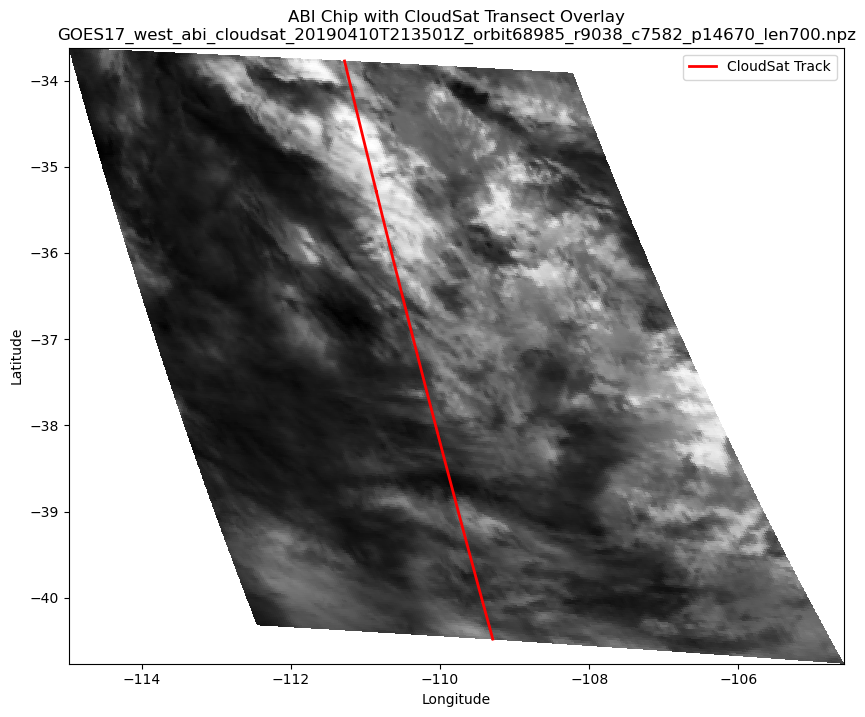

In [21]:
half = 256

file = '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T213501Z_orbit68985_r9038_c7582_p14670_len700.npz'


archive = open_npz_file(file)



# print(archive.files)

chip = archive['chip']
print(chip.shape)

cloudsat_latitude = archive['cloudsat_latitude'] 
cloudsat_longitude = archive['cloudsat_longitude'] 
# cloudsat_longitude[cloudsat_longitude < 0] += 360

print(cloudsat_latitude.shape, cloudsat_longitude.shape)

#  'cloudsat_latitude', 'cloudsat_longitude' is what we need for the vis

# print(archive['cloudsat_latitude'].shape) # it matches the len which is a good sign

fileName = file.split('/')[-1]
# print(fileName) # GOES16_east_abi_cloudsat_20190410T151908Z_orbit68981_r2556_c9238_p21510_len603.npz
# r c p is row column is profile index

fileNameSplit = fileName.split('_')
print(fileNameSplit)

row =re.sub(r'[^0-9]', '', fileNameSplit[-4]) 
col = re.sub(r'[^0-9]', '', fileNameSplit[-3])
eastOrWest = fileNameSplit[1]


print(row, col)

y_center = int(row)
x_center = int(col)


lat_chip = 'placeholder'
lon_chip = 'placeholder'

if eastOrWest == 'east':
    lat_chip = EAST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = EAST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    print('east')
else:
    lat_chip = WEST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = WEST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    print('west')

# print(lat_chip, lon_chip)


abi_image = chip[2, :, :, 12]
visualize_chip(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude, fileName)


   



In [ ]:
file = '/explore/nobackup/projects/pix4dcloud/aliewehr/oneDayTests/goes17/1600_bound/GOES17_west_abi_cloudsat_20190410T213501Z_orbit68985_r9038_c7582_p14670_len700.npz'
archive = open_npz_file(file)


print('all fields:', archive.files)

# for field in archive.files:
#     print(field, archive[field])

print('chip shape:', archive['chip'].shape)

print(archive['abi_offsets_minutes'])


print(archive['abi_valid_mask']) # what does this mean??? if a certain timestep is valid (no issues, 1) or invalid (has an issue, 0)


print(archive['abi_scan_times']) # these are the actual times of the 7 time steps

print(archive['metadata_json']) # metadata about the chip

print(archive['cloudsat_latitude'].shape) # the cloudsat transect locatations
print(archive['cloudsat_longitude'].shape)


print(archive['cloudsat_utc_hour'].shape) # the time at which each cloudsat footprint was taken


print(archive['cloudsat_quality'].shape) # what does this mean?


print(archive['cloudsat_cloud_layer_base'].shape) 
print(archive['cloudsat_cloud_layer_top'].shape) 
print(archive['cloudsat_cloud_layer_type'].shape) 
print(archive['cloudsat_cloud_layer_count'].shape) 
print('mask', archive['cloudsat_cloud_mask'].shape) # what the actualy cloud type is
print('binary mask', archive['cloudsat_cloud_mask_binary'].shape) # binary is if there is a cloud (1) or not (0)
print(archive['cloudsat_profile_valid'].shape) 
print(archive['cloudsat_abi_row'].shape) 
print(archive['cloudsat_abi_column'].shape) 
print(archive['cloudsat_profile_index'].shape) 


all fields: ['chip', 'abi_offsets_minutes', 'abi_valid_mask', 'abi_scan_times', 'metadata_json', 'cloudsat_latitude', 'cloudsat_longitude', 'cloudsat_utc_hour', 'cloudsat_quality', 'cloudsat_cloud_layer_base', 'cloudsat_cloud_layer_top', 'cloudsat_cloud_layer_type', 'cloudsat_cloud_layer_count', 'cloudsat_cloud_mask', 'cloudsat_cloud_mask_binary', 'cloudsat_profile_valid', 'cloudsat_abi_row', 'cloudsat_abi_column', 'cloudsat_profile_index']
chip shape: (7, 512, 512, 16)
[-60 -40 -20   0  20  40  60]
[1 1 1 1 1 1 1]
['2019-04-10T20:30:34+00:00' '2019-04-10T20:50:34+00:00'
 '2019-04-10T21:10:33+00:00' '2019-04-10T21:30:33+00:00'
 '2019-04-10T21:50:33+00:00' '2019-04-10T22:10:33+00:00'
 '2019-04-10T22:30:33+00:00']
{"abi_column":7582,"abi_common_grid_resolution_km":1.0,"abi_geometry_source":"/explore/nobackup/projects/pix4dcloud/jgong/ABI_WEST_GEO_TOPO_LOMSK.nc","abi_inner_disk_margin":1600,"abi_root":"/css/geostationary/NonOptimized/L1/GOES-17-ABI-L1B-FULLD","abi_row":9038,"abi_valid_fra